# Predicting Lattice Thermal Conductivity (κ_L) with Machine Learning

> **Dataset:** AFLOW Materials Database — 5,530 crystalline compounds  
> **Target:** Lattice thermal conductivity κ_L (W/mK)  
> **Features:** Crystal structure, composition & electronic properties only  
> **Models:** Linear Regression → Random Forest → XGBoost → LightGBM  

---

## Table of Contents
1. [Setup & Data Loading](#1-setup--data-loading)
2. [Feature Engineering](#2-feature-engineering)
3. [Data Quality Check](#3-data-quality-check)
4. [Removing Leaky Features](#4-removing-leaky-features)
5. [Encoding & Train/Val/Test Split](#5-encoding--trainvaltest-split)
6. [Target Distribution](#6-target-distribution)
7. [Model Training](#7-model-training)
8. [Model Comparison](#8-model-comparison)
9. [SHAP Feature Importance](#9-shap-feature-importance)
10. [Lean Model — Top 10 Features](#10-lean-model--top-10-features)
11. [Save Model](#11-save-model)


---
## 1. Setup & Data Loading

The dataset comes from the [AFLOW](http://www.aflowlib.org/) (Automatic FLOW for
Materials Discovery) database — a large repository of DFT-computed material
properties. Each row is a crystalline compound described by 173 features.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('thermal_conductivity_dataset.csv')
print(f'Dataset shape: {df.shape}')
print(f'Target range : {df["thermal_conductivity_target"].min():.3f} – '
      f'{df["thermal_conductivity_target"].max():.3f} W/mK')
df.head()


Dataset shape: (5530, 173)
Target range : 0.010 – 420.468 W/mK


,compound,thermal_conductivity_target,Bravais_lattice_lattice_system,Bravais_lattice_lattice_system_orig,Bravais_lattice_lattice_type,Bravais_lattice_lattice_type_orig,Bravais_lattice_lattice_variation_type,Bravais_lattice_lattice_variation_type_orig,Bravais_lattice_orig,Bravais_lattice_relax,...,spin_cell,stoichiometry,stress_tensor,title,valence_cell_iupac,valence_cell_std,volume_atom,volume_atom_orig,volume_cell_orig,volume_cell_x
0,Ac1H2_ICSD_56392.cif,6.30231,cubic,cubic,FCC,FCC,FCC,FCC,FCC,FCC,...,0.0,"[0.333333333, 0.666666667]","[-1.07, 0, 0, 0, -1.07, 0, 0, 0, -1.07]",Ac1H2_ICSD_56392,5,5,17.0642,15.1904,45.5711,51.1926
1,Ag1Al1O2_ICSD_160643.cif,2.40141,orthorhombic,orthorhombic,ORC,ORC,ORC,ORC,ORC,ORC,...,0.0,"[0.25, 0.25, 0.5]","[1.6, 0, 0, 0, 0.06, 0, 0, 0, 1.31]",Ag1Al1O2_ICSD_160643,44,104,13.2165,11.9753,191.6060,211.4640
2,Ag1Al1O2_ICSD_300020.cif,4.10466,hexagonal,hexagonal,HEX,HEX,HEX,HEX,HEX,HEX,...,0.0,"[0.25, 0.25, 0.5]","[1.38, 0, 0, 0, 1.37, 0, 0, 0, -0.32]",Ag1Al1O2_ICSD_300020,22,52,11.4261,11.0936,88.7490,91.4090
3,Ag1Al1S2_ICSD_25356.cif,5.04353,hexagonal,hexagonal,HEX,HEX,HEX,HEX,HEX,HEX,...,0.0,"[0.25, 0.25, 0.5]","[-0.58, 0, 0, 0, -0.58, 0, 0, 0, -1.89]",Ag1Al1S2_ICSD_25356,19,26,18.9060,18.1411,72.5643,75.6238
4,Ag1Al1Se2_ICSD_28745.cif,1.29014,tetragonal,tetragonal,BCT,BCT,BCT2,BCT2,BCT,BCT,...,0.0,"[0.25, 0.25, 0.5]","[-1.07, 0, 0, 0, -1.07, 0, 0, 0, -2.07]",Ag1Al1Se2_ICSD_28745,38,52,25.5295,23.8341,190.6720,204.2360


---
## 2. Feature Engineering

Raw AFLOW data contains 173 columns. We reduce these in two passes:

**Pass 1 — Remove metadata & raw arrays** (173 → 88 columns)

| Dropped group | Examples |
|---|---|
| Metadata | `aflow_version`, `aurl`, `catalog`, `code` |
| `_orig` duplicates | `Bravais_lattice_lattice_system_orig`, ... |
| Raw arrays | `forces`, `stress_tensor`, `positions_cartesian` |
| DFT settings | `dft_type`, `ldau_*`, `species_pp` |

**Pass 2 — Remove redundant features** (88 → 52 columns)

| Dropped group | Examples |
|---|---|
| Redundant structural | `Bravais_lattice_relax`, `crystal_class` |
| Cell duplicates of atom | `energy_cell` (keep `energy_atom`) |
| Reuss/Voigt (keep VRH) | `ael_bulk_modulus_reuss`, `ael_bulk_modulus_voigt` |
| High-cardinality strings | `compound`, `stoichiometry`, `species` |


In [2]:
# ── Pass 1: Remove metadata, _orig duplicates, raw arrays, DFT settings ──────
drop_cols = [
    'aflow_version','aflowlib_date','aflowlib_version','aurl',
    'calculation_cores','calculation_memory','calculation_time',
    'catalog','code','data_api','data_source','files','loop',
    'node_CPU_Cores','node_CPU_MHz','node_CPU_Model','node_RAM_GB',
    'title','kpoints','kpoints_bands_nkpts','kpoints_bands_path',
    'kpoints_relax','kpoints_static','energy_cutoff',
    'delta_electronic_energy_convergence','delta_electronic_energy_threshold',
    'Bravais_lattice_lattice_system_orig','Bravais_lattice_lattice_type_orig',
    'Bravais_lattice_lattice_variation_type_orig','Bravais_lattice_orig',
    'Bravais_superlattice_lattice_system_orig','Bravais_superlattice_lattice_type_orig',
    'Bravais_superlattice_lattice_variation_type_orig',
    'Pearson_symbol_orig','Pearson_symbol_superlattice_orig',
    'Wyckoff_letters_orig','Wyckoff_multiplicities_orig','Wyckoff_site_symmetries_orig',
    'crystal_class_orig','crystal_family_orig','crystal_system_orig',
    'density_orig','geometry_orig','lattice_system_orig','lattice_variation_orig',
    'point_group_Hermann_Mauguin_orig','point_group_Schoenflies_orig',
    'point_group_orbifold_orig','point_group_order_orig',
    'point_group_structure_orig','point_group_type_orig',
    'reciprocal_geometry_orig','reciprocal_lattice_type_orig',
    'reciprocal_lattice_variation_type_orig','reciprocal_volume_cell_orig',
    'spacegroup_orig_x','volume_atom_orig','volume_cell_orig',
    'anrl_label_orig','anrl_parameter_list_orig','anrl_parameter_values_orig',
    'forces','positions_cartesian','positions_fractional',
    'stress_tensor','bader_atomic_volumes','bader_net_charges',
    'nbondxx','geometry','anrl_parameter_list_relax','anrl_parameter_values_relax',
    'dft_type','ldau_TLUJ','ldau_j','ldau_l','ldau_type','ldau_u',
    'species_pp','species_pp_ZVAL','species_pp_version',
    'pressure','pressure_residual','ael_applied_pressure',
    'ael_average_external_pressure','Pulay_stress',
]
df_clean = df.drop(columns=[c for c in drop_cols if c in df.columns])

# ── Pass 2: Remove redundant features ─────────────────────────────────────────
drop_final = [
    'Bravais_lattice_relax','Bravais_superlattice_lattice_system',
    'Bravais_superlattice_lattice_type','Bravais_superlattice_lattice_variation_type',
    'lattice_system_relax','lattice_variation_relax',
    'crystal_class','crystal_family',
    'reciprocal_lattice_type','reciprocal_lattice_variation_type',
    'sg2','natoms_orig',
    'energy_cell','enthalpy_cell','eentropy_cell','PV_cell',
    'agl_vibrational_entropy_300K_cell','agl_vibrational_free_energy_300K_cell',
    'agl_bulk_modulus_static_300K','volume_cell_x',
    'ael_bulk_modulus_reuss','ael_bulk_modulus_voigt',
    'ael_shear_modulus_reuss','ael_shear_modulus_voigt',
    'spin_cell','agl_poisson_ratio_source',
    'compound','composition','Wyckoff_letters','Wyckoff_site_symmetries',
    'Pearson_symbol_superlattice','anrl_label_relax','prototype',
    'reciprocal_geometry','stoichiometry','species',
]
df_final = df_clean.drop(columns=[c for c in drop_final if c in df_clean.columns])

print(f'Pass 1: {df.shape[1]} → {df_clean.shape[1]} columns')
print(f'Pass 2: {df_clean.shape[1]} → {df_final.shape[1]} columns')


Pass 1: 173 → 88 columns
Pass 2: 88 → 52 columns


---
## 3. Data Quality Check

Verify there are no missing values and understand the type breakdown
of the 52 remaining features.


In [3]:
# Missing values
missing = df_final.isnull().sum()
n_missing = (missing > 0).sum()
print(f'Columns with missing values: {n_missing} / {df_final.shape[1]}')

# Type breakdown
print(f'\nDtype breakdown:')
print(df_final.dtypes.value_counts().to_string())

# Categorical cardinality
cat_cols = df_final.select_dtypes(include='object').columns
print(f'\nCategorical columns ({len(cat_cols)}):')
for col in cat_cols:
    print(f'  {col:<45s} {df_final[col].nunique():>4d} unique values')


Columns with missing values: 0 / 52

Dtype breakdown:
float64    31
str        14
int64       7

Categorical columns (14):
  Bravais_lattice_lattice_system                   7 unique values
  Bravais_lattice_lattice_type                    14 unique values
  Bravais_lattice_lattice_variation_type          19 unique values
  Egap_type                                        6 unique values
  Pearson_symbol_relax                           224 unique values
  Wyckoff_multiplicities                         857 unique values
  crystal_system                                   7 unique values
  point_group_Hermann_Mauguin                     27 unique values
  point_group_Schoenflies                         27 unique values
  point_group_orbifold                            27 unique values
  point_group_structure                            9 unique values
  point_group_type                                 4 unique values
  sg                                             175 unique values
  spin

---
## 4. Removing Leaky Features

The AFLOW database computes κ_L via the **Slack model** inside its AGL pipeline.
Several other features are **co-outputs or direct inputs** of the same calculation
— including them gives the model near-perfect information about the target.

| Leaky group | Features | Why removed |
|---|---|---|
| **AGL thermal outputs** | `agl_acoustic_debye`, `agl_gruneisen`, `agl_heat_capacity_*`, ... | Same Debye–Grüneisen model that computes κ_L |
| **AEL sound velocities** | `ael_speed_sound_*`, `ael_debye_temperature` | Appear directly in Slack formula: κ_L ∝ v³ |
| **AEL elastic moduli** | `ael_bulk/shear/youngs_modulus_*`, `ael_poisson_ratio`, ... | Upstream Slack inputs: κ_L ∝ E^(3/2) — linear model recovers R²≈0.92 from these alone |
| **Phonon mean free path** | `scintillation_attenuation_length` | In AFLOW this is λ from BTE; κ_L = ⅓·C·v·λ |
| **High-cardinality encoded** | `sg` (175 groups), `Pearson_symbol_relax` (224 groups) | ~25–31 samples/group → target encoding memorises individual values |

**What remains:** crystal symmetry, volume, density, band gap, DFT energies,
valence electrons — all computed **independently** of κ_L.


In [4]:
# AGL: co-outputs of the Debye–Grüneisen model
agl_leaky = [
    'agl_acoustic_debye','agl_bulk_modulus_isothermal_300K','agl_bulk_modulus_static_300K',
    'agl_debye','agl_gruneisen','agl_heat_capacity_Cp_300K','agl_heat_capacity_Cv_300K',
    'agl_poisson_ratio_source','agl_thermal_expansion_300K',
    'agl_vibrational_entropy_300K_atom','agl_vibrational_entropy_300K_cell',
    'agl_vibrational_free_energy_300K_atom','agl_vibrational_free_energy_300K_cell',
]
# AEL: sound velocities + Debye temperature (in Slack formula)
ael_sound = [
    'ael_debye_temperature',
    'ael_speed_sound_average','ael_speed_sound_longitudinal','ael_speed_sound_transverse',
]
# AEL: elastic moduli (upstream Slack inputs, κ_L ∝ E^3/2)
ael_elastic = [
    'ael_bulk_modulus_vrh','ael_bulk_modulus_reuss','ael_bulk_modulus_voigt',
    'ael_shear_modulus_vrh','ael_shear_modulus_reuss','ael_shear_modulus_voigt',
    'ael_youngs_modulus_vrh','ael_poisson_ratio','ael_pughs_modulus_ratio','ael_elastic_anisotropy',
]
# Phonon mean free path (κ_L = 1/3·C·v·λ)
phonon_mfp = ['scintillation_attenuation_length']
# High-cardinality categoricals
high_card  = ['sg','spacegroup_relax','Pearson_symbol_relax']

all_leaky = agl_leaky + ael_sound + ael_elastic + phonon_mfp + high_card
df_model  = df_final.drop(columns=[c for c in all_leaky if c in df_final.columns])

dropped   = len([c for c in all_leaky if c in df_final.columns])
print(f'Features dropped : {dropped}')
print(f'Features remaining: {df_model.shape[1]}')
print(f'\nFinal feature list:')
for c in df_model.columns:
    if c != 'thermal_conductivity_target':
        print(f'  {c}')


Features dropped : 23
Features remaining: 29

Final feature list:
  Bravais_lattice_lattice_system
  Bravais_lattice_lattice_type
  Bravais_lattice_lattice_variation_type
  Egap_fit
  Egap_type
  Egap_x
  PV_atom
  Wyckoff_multiplicities
  crystal_system
  density_x
  eentropy_atom
  energy_atom
  enthalpy_atom_x
  natoms_x
  nspecies_x
  point_group_Hermann_Mauguin
  point_group_Schoenflies
  point_group_orbifold
  point_group_order
  point_group_structure
  point_group_type
  reciprocal_volume_cell
  spinD
  spinF
  spin_atom_x
  valence_cell_iupac
  valence_cell_std
  volume_atom


---
## 5. Encoding & Train/Val/Test Split

All remaining categoricals have ≤ 19 unique values — safely **one-hot encoded**.
No target encoding is used (eliminates another leakage source).
The **split happens before encoding** so no test information leaks into features.

The target `κ_L` is **log-transformed** (`log(1 + κ_L)`) to normalise its
right-skewed distribution before modelling.

| Split | Ratio | Samples |
|---|---|---|
| Train | 80% | ~4,424 |
| Validation | 10% | ~553 |
| Test | 10% | ~553 |


In [5]:
from sklearn.model_selection import train_test_split

# Drop un-encodable / redundant string columns
drop_str = [
    'crystal_system','point_group_Hermann_Mauguin',
    'point_group_Schoenflies','point_group_orbifold',
    'spinD','Wyckoff_multiplicities',
]
df_enc = df_model.drop(columns=[c for c in drop_str if c in df_model.columns]).copy()

# One-hot encode categoricals
onehot_cols = [
    'Bravais_lattice_lattice_system','Bravais_lattice_lattice_type',
    'Bravais_lattice_lattice_variation_type',
    'Egap_type','point_group_type','point_group_structure',
]
df_enc = pd.get_dummies(
    df_enc, columns=[c for c in onehot_cols if c in df_enc.columns], drop_first=False
)

# Log-transform target
df_enc['log_kl'] = np.log1p(df_enc['thermal_conductivity_target'])
df_enc = df_enc.drop(columns=['thermal_conductivity_target'])

# Split
X = df_enc.drop(columns=['log_kl'])
y = df_enc['log_kl']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
X_train, X_val,  y_train, y_val  = train_test_split(X_train, y_train, test_size=0.111, random_state=42)

# Bool → int
for split in [X_train, X_val, X_test]:
    bc = split.select_dtypes(include='bool').columns
    split[bc] = split[bc].astype(int)

print(f'Train : {X_train.shape}')
print(f'Val   : {X_val.shape}')
print(f'Test  : {X_test.shape}')
print(f'\nFeature count: {X_train.shape[1]}')


Train : (4424, 75)
Val   : (553, 75)
Test  : (553, 75)

Feature count: 75


---
## 6. Target Distribution

The raw κ_L distribution is heavily right-skewed (most materials have low
conductivity, a few have very high values). The log transform produces an
approximately normal distribution that helps all regression models converge.


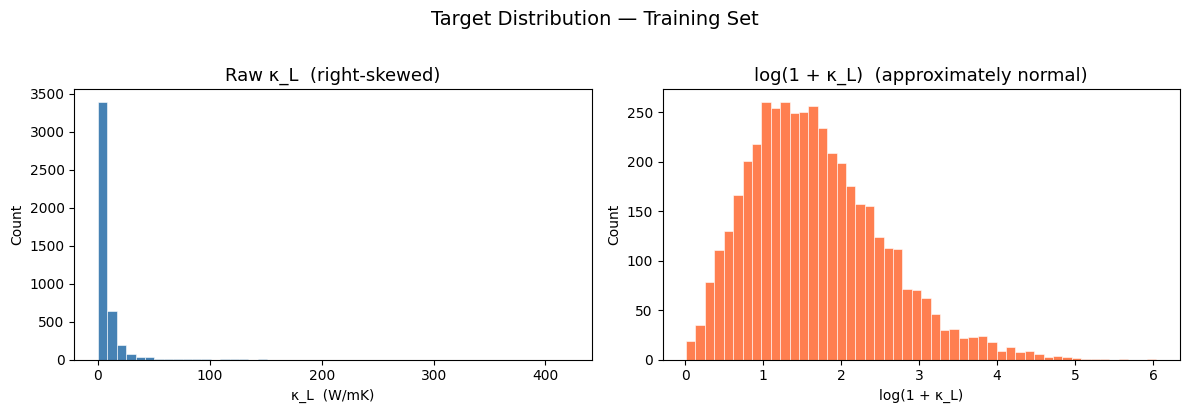

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(np.expm1(y_train), bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_title('Raw κ_L  (right-skewed)', fontsize=13)
axes[0].set_xlabel('κ_L  (W/mK)')
axes[0].set_ylabel('Count')

axes[1].hist(y_train, bins=50, color='coral', edgecolor='white', linewidth=0.4)
axes[1].set_title('log(1 + κ_L)  (approximately normal)', fontsize=13)
axes[1].set_xlabel('log(1 + κ_L)')
axes[1].set_ylabel('Count')

plt.suptitle('Target Distribution — Training Set', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 7. Model Training

We train four models in order of increasing complexity, all predicting
`log(1 + κ_L)` on the same features.

A shared `evaluate()` helper computes metrics on the original W/mK scale
and stores results for the final comparison.


In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

results = {}

def evaluate(name, model, X, y_true):
    """Predict, score, store and print results."""
    y_log  = model.predict(X)
    y_pred = np.expm1(y_log)
    y_true_orig = np.expm1(y_true)

    r2   = 1 - np.sum((y_true - y_log)**2) / np.sum((y_true - y_true.mean())**2)
    mae  = mean_absolute_error(y_true_orig, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred))

    results[name] = dict(R2=r2, MAE=mae, RMSE=rmse)
    print(f'  R²   = {r2:.4f}')
    print(f'  MAE  = {mae:.4f} W/mK')
    print(f'  RMSE = {rmse:.4f} W/mK')
    return r2, mae, rmse


### 7.1 Linear Regression (Ridge)

Simplest baseline. Ridge regularisation handles multicollinearity among correlated
structural features. Features are standardised first.


In [8]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

lr = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))])
lr.fit(X_train, y_train)

print('── Linear Regression — Test ──')
evaluate('Linear Regression', lr, X_test, y_test)


── Linear Regression — Test ──
  R²   = 0.7364
  MAE  = 3.1565 W/mK
  RMSE = 10.3734 W/mK


(np.float64(0.7363679472889575),
 3.1564607162870804,
 np.float64(10.373437350591917))

### 7.2 Random Forest

Bagged ensemble of decision trees — captures non-linearities and feature
interactions that a linear model cannot.


In [9]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300, min_samples_split=5, min_samples_leaf=2,
    max_features=0.3, n_jobs=-1, random_state=42,
)
rf.fit(X_train, y_train)

print('── Random Forest — Test ──')
evaluate('Random Forest', rf, X_test, y_test)


── Random Forest — Test ──
  R²   = 0.8323
  MAE  = 2.7044 W/mK
  RMSE = 10.4002 W/mK


(np.float64(0.8322845926294608),
 2.7043684054543893,
 np.float64(10.400246815685335))

### 7.3 XGBoost

Sequential gradient boosting — each tree corrects the previous residuals.
Early stopping on the validation set guards against overfitting.


In [10]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=1000, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=0.1,
    early_stopping_rounds=50, eval_metric='rmse', random_state=42, verbosity=0,
)
xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)

print('\n── XGBoost — Test ──')
evaluate('XGBoost', xgb, X_test, y_test)


[0]	validation_0-rmse:0.82981
[100]	validation_0-rmse:0.35763
[200]	validation_0-rmse:0.34470
[300]	validation_0-rmse:0.33666
[400]	validation_0-rmse:0.33147
[500]	validation_0-rmse:0.32906
[600]	validation_0-rmse:0.32728
[700]	validation_0-rmse:0.32613
[800]	validation_0-rmse:0.32510
[900]	validation_0-rmse:0.32439
[999]	validation_0-rmse:0.32372

── XGBoost — Test ──
  R²   = 0.8565
  MAE  = 2.3440 W/mK
  RMSE = 9.5854 W/mK


(np.float64(0.8564657458169582),
 2.3439592445950916,
 np.float64(9.585372994157284))

### 7.4 LightGBM

Leaf-wise gradient boosting with histogram-based splits — typically faster
than XGBoost while matching or beating its accuracy on tabular data.


In [11]:
import lightgbm as lgb

params = {
    'objective':'regression', 'metric':['mae','rmse'],
    'learning_rate':0.05, 'num_leaves':63, 'max_depth':-1,
    'min_child_samples':20, 'feature_fraction':0.8,
    'bagging_fraction':0.8, 'bagging_freq':5,
    'lambda_l1':0.1, 'lambda_l2':0.1, 'verbose':-1, 'random_state':42,
}
callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),
    lgb.log_evaluation(period=100),
]
lgbm = lgb.train(
    params,
    lgb.Dataset(X_train, label=y_train),
    num_boost_round=1000,
    valid_sets=[lgb.Dataset(X_val, label=y_val)],
    valid_names=['val'],
    callbacks=callbacks,
)

print('\n── LightGBM — Test ──')
evaluate('LightGBM', lgbm, X_test, y_test)


Training until validation scores don't improve for 50 rounds
[100]	val's l1: 0.265075	val's rmse: 0.354333
[200]	val's l1: 0.252063	val's rmse: 0.339665
[300]	val's l1: 0.245747	val's rmse: 0.334274
[400]	val's l1: 0.241285	val's rmse: 0.33073
[500]	val's l1: 0.240349	val's rmse: 0.330552
Early stopping, best iteration is:
[476]	val's l1: 0.24044	val's rmse: 0.330183

── LightGBM — Test ──
  R²   = 0.8518
  MAE  = 2.3051 W/mK
  RMSE = 9.5241 W/mK


(np.float64(0.8518337767343156),
 2.3051371157131952,
 np.float64(9.524117133211176))

---
## 8. Model Comparison

All four models evaluated on the held-out test set.


In [12]:
header = f"{'Model':<22} {'R²':>8} {'MAE (W/mK)':>12} {'RMSE (W/mK)':>13}"
print(header)
print('─' * len(header))
for name, m in sorted(results.items(), key=lambda x: x[1]['R2']):
    print(f"{name:<22} {m['R2']:>8.4f} {m['MAE']:>12.4f} {m['RMSE']:>13.4f}")


Model                        R²   MAE (W/mK)   RMSE (W/mK)
──────────────────────────────────────────────────────────
Linear Regression        0.7364       3.1565       10.3734
Random Forest            0.8323       2.7044       10.4002
LightGBM                 0.8518       2.3051        9.5241
XGBoost                  0.8565       2.3440        9.5854


---
## 9. SHAP Feature Importance

[SHAP](https://shap.readthedocs.io/) (SHapley Additive exPlanations) assigns each
feature a contribution value for each individual prediction, grounded in cooperative
game theory — more reliable than standard importance metrics.

- **Y-axis** — features ranked by mean |SHAP| across the test set
- **X-axis** — SHAP value: positive → pushes κ_L prediction up
- **Colour** — feature value (red = high, blue = low)


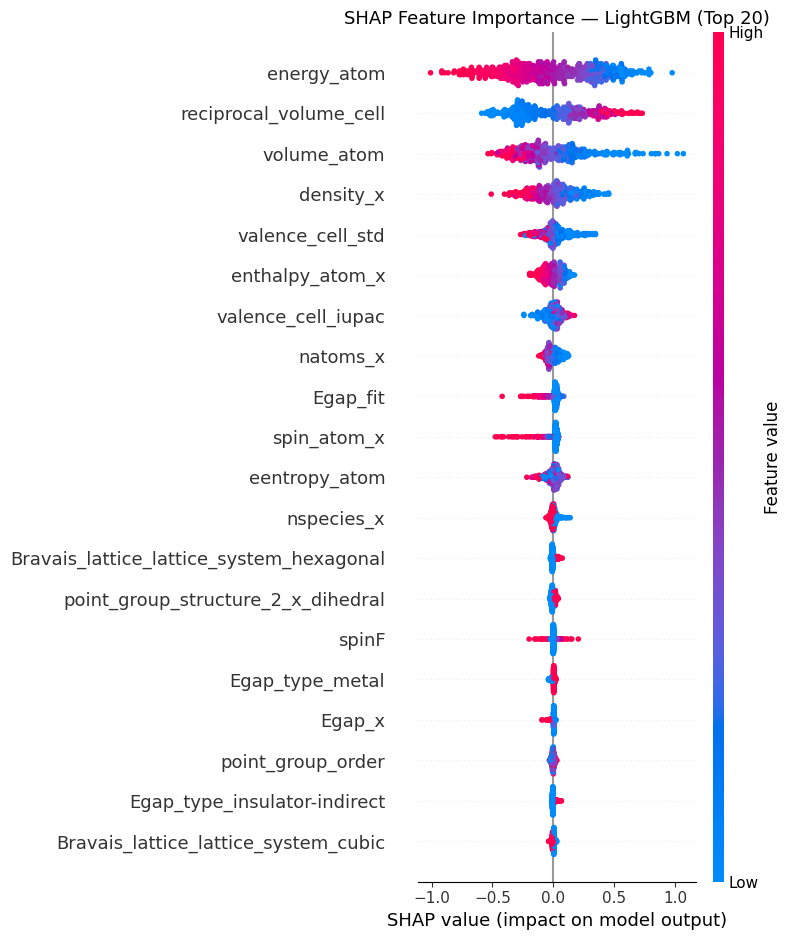

Top 15 features by SHAP importance:
                                 feature  mean_shap
                             energy_atom   0.324363
                  reciprocal_volume_cell   0.253046
                             volume_atom   0.212153
                               density_x   0.130603
                        valence_cell_std   0.076058
                         enthalpy_atom_x   0.059925
                      valence_cell_iupac   0.042008
                                natoms_x   0.041579
                                Egap_fit   0.037456
                             spin_atom_x   0.036657
                           eentropy_atom   0.035155
                              nspecies_x   0.015159
Bravais_lattice_lattice_system_hexagonal   0.012024
      point_group_structure_2_x_dihedral   0.011725
                                   spinF   0.008291


In [13]:
import shap

explainer   = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, max_display=20, show=False)
plt.title('SHAP Feature Importance — LightGBM (Top 20)', fontsize=13)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

shap_importance = (
    pd.DataFrame({'feature': X_test.columns,
                  'mean_shap': np.abs(shap_values).mean(axis=0)})
    .sort_values('mean_shap', ascending=False)
)
print('Top 15 features by SHAP importance:')
print(shap_importance.head(15).to_string(index=False))


---
## 10. Lean Model — Top 10 Features

Retrain LightGBM using only the 10 highest-SHAP features.
A lean model is easier to interpret, deploy, and explain to domain experts —
and often generalises slightly better by excluding noisy features.


In [14]:
top10 = shap_importance.head(10)['feature'].tolist()
print('Top 10 features:', top10)

lgbm_top10 = lgb.train(
    params,
    lgb.Dataset(X_train[top10], label=y_train),
    num_boost_round=1000,
    valid_sets=[lgb.Dataset(X_val[top10], label=y_val)],
    valid_names=['val'],
    callbacks=callbacks,
)

print('\n── LightGBM Top-10 — Test ──')
evaluate('LightGBM Top-10', lgbm_top10, X_test[top10], y_test)

print('\n── Full model vs Lean model ──')
header = f"{'Model':<22} {'R²':>8} {'MAE (W/mK)':>12} {'RMSE (W/mK)':>13}"
print(header)
print('─' * len(header))
for name in ['LightGBM', 'LightGBM Top-10']:
    m = results[name]
    print(f"{name:<22} {m['R2']:>8.4f} {m['MAE']:>12.4f} {m['RMSE']:>13.4f}")


Top 10 features: ['energy_atom', 'reciprocal_volume_cell', 'volume_atom', 'density_x', 'valence_cell_std', 'enthalpy_atom_x', 'valence_cell_iupac', 'natoms_x', 'Egap_fit', 'spin_atom_x']
Training until validation scores don't improve for 50 rounds
[100]	val's l1: 0.266871	val's rmse: 0.36183
[200]	val's l1: 0.255528	val's rmse: 0.350476
[300]	val's l1: 0.249817	val's rmse: 0.345029
[400]	val's l1: 0.247677	val's rmse: 0.342665
Early stopping, best iteration is:
[425]	val's l1: 0.247049	val's rmse: 0.342023

── LightGBM Top-10 — Test ──
  R²   = 0.8188
  MAE  = 2.6317 W/mK
  RMSE = 9.9671 W/mK

── Full model vs Lean model ──
Model                        R²   MAE (W/mK)   RMSE (W/mK)
──────────────────────────────────────────────────────────
LightGBM                 0.8518       2.3051        9.5241
LightGBM Top-10          0.8188       2.6317        9.9671


---
## 11. Save Model

Serialise the final lean model and its feature list for downstream use
(inference pipelines, web APIs, further research).


In [15]:
import joblib

joblib.dump(lgbm_top10, 'kl_predictor_lgbm.pkl')
joblib.dump(top10,       'kl_top10_features.pkl')
print('Model saved  → kl_predictor_lgbm.pkl')
print('Features saved → kl_top10_features.pkl')

# Sanity check
sample = X_test[top10].iloc[[0]]
pred   = np.expm1(lgbm_top10.predict(sample))[0]
true   = np.expm1(y_test.iloc[0])
print(f'\nSample prediction : {pred:.4f} W/mK')
print(f'True value        : {true:.4f} W/mK')


Model saved  → kl_predictor_lgbm.pkl
Features saved → kl_top10_features.pkl

Sample prediction : 8.7726 W/mK
True value        : 11.9917 W/mK
